In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [3]:
columns = ["id", "square_meters", "age", "price"]

df = pd.read_csv("../data/housing.csv", index_col=0, usecols=columns)
df.head()

,square_meters,age,price
id,,,
1,51,5,105700
2,52,44,90000
3,56,36,102800
4,57,6,119400
5,58,21,103900


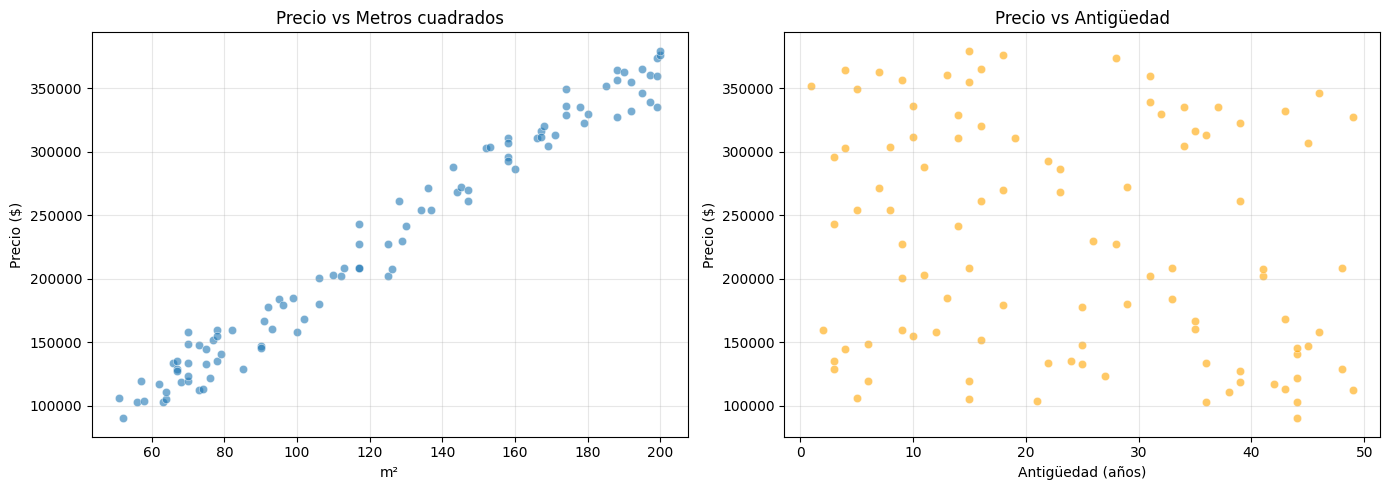

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x="square_meters", y="price", data=df, ax=axes[0], alpha=0.6)
axes[0].set_title("Precio vs Metros cuadrados")
axes[0].set_xlabel("m²")
axes[0].set_ylabel("Precio ($)")
axes[0].grid(True, alpha=0.3)

sns.scatterplot(x="age", y="price", data=df, ax=axes[1], alpha=0.6, color="orange")
axes[1].set_title("Precio vs Antigüedad")
axes[1].set_xlabel("Antigüedad (años)")
axes[1].set_ylabel("Precio ($)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

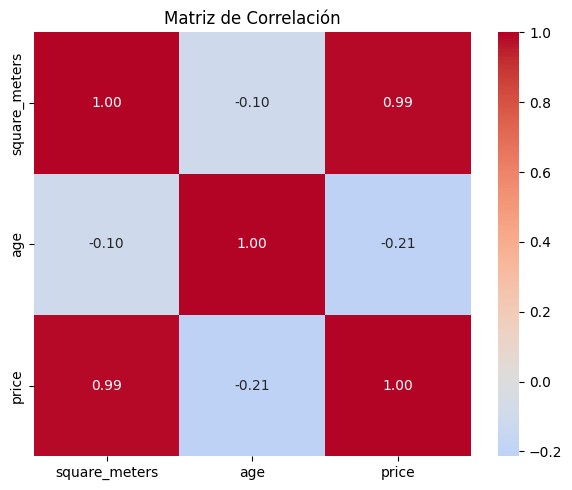

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax
)
ax.set_title("Matriz de Correlación")
plt.tight_layout()
plt.show()

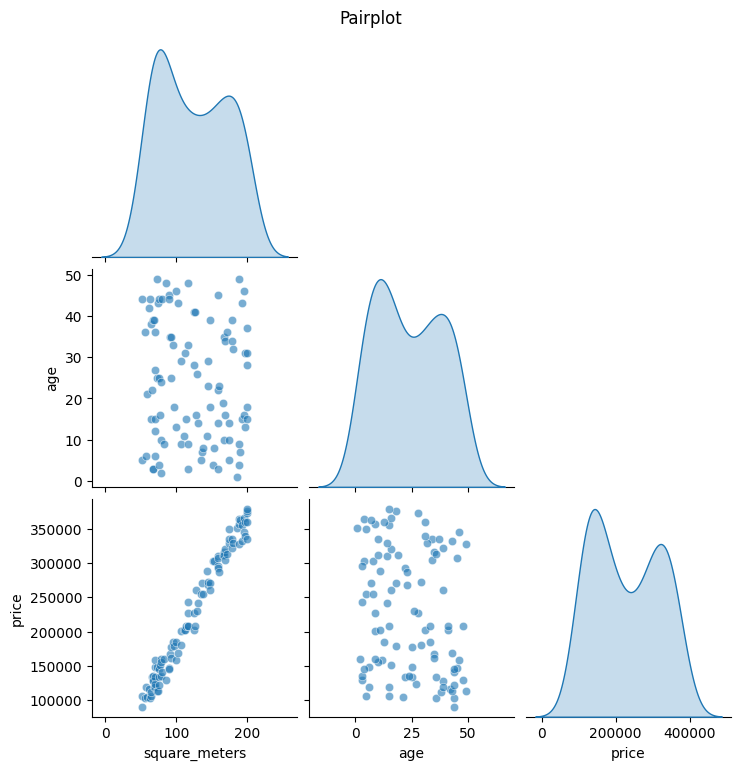

In [29]:
sns.pairplot(df, corner=True, diag_kind="kde", plot_kws={"alpha": 0.6})
plt.suptitle("Pairplot", y=1.02)
plt.show()

In [6]:
model = LinearRegression()
X = df[["square_meters", "age"]]
y = df["price"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

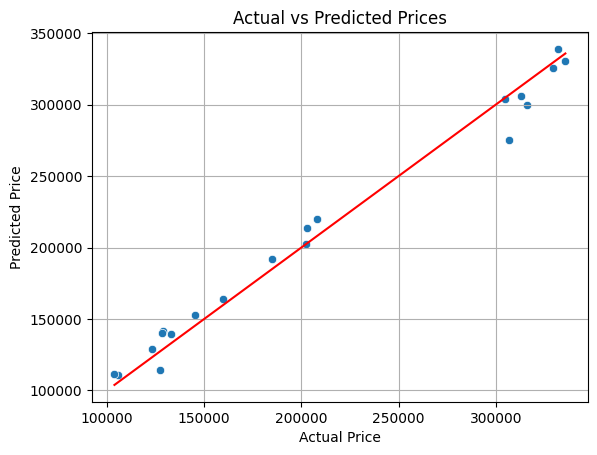

In [7]:
sns.scatterplot(x=y_test, y=y_pred)
sns.lineplot(x=y_test, y=y_test, color="red")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.grid()
plt.show()

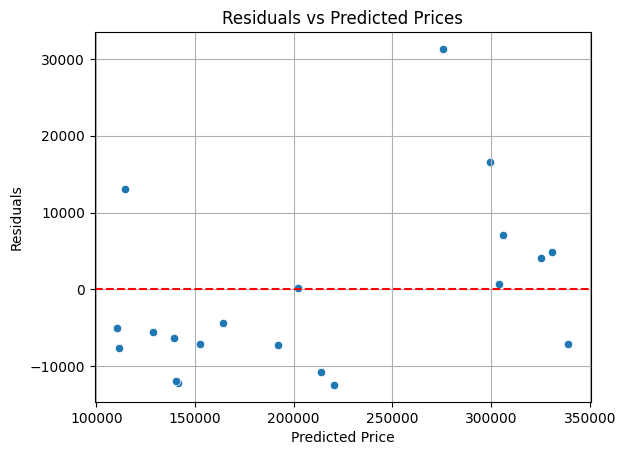

In [8]:
residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Prices")
plt.grid()
plt.show()